In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/filed/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4


In [4]:
from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["nox", "NOx", "O3", "CH4"], bounds)
mask_by_validity_range(fleeto, ["nox", "NOx", "O3", "CH4"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4


In [5]:
from cane.utils import df_diff

# create aggregates (total)
org_sum = (
    dff[["flight_id", "fuel_burn", "nox", "NOx", "CoCiP"]]
    .groupby(["flight_id"]).sum().reset_index()
)
opt_sum = (
    dfo[["flight_id", "fuel_burn", "nox", "NOx", "CoCiP"]]
    .groupby(["flight_id"]).sum().reset_index()
)
my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
my_diff = pd.merge(
    my_diff,
    dff.groupby("flight_id").day.first(),
    on="flight_id",
)

In [6]:
# my_diff = my_diff.query("nox_optimised != 0").reset_index(drop=True)
# print(my_diff.shape[0], "flights")

In [7]:
cols = ["nox_diff", "NOx_diff"]
res = pd.merge(
    my_diff.groupby("day").size().rename("count"),
    my_diff.groupby("day")[cols].apply(lambda g: (g > 0).sum()),
    on="day"
)
res_rel = res.div(res["count"], axis=0) * 100

In [8]:
# res_rel["nox_diff"] - res_rel["NOx_diff"]

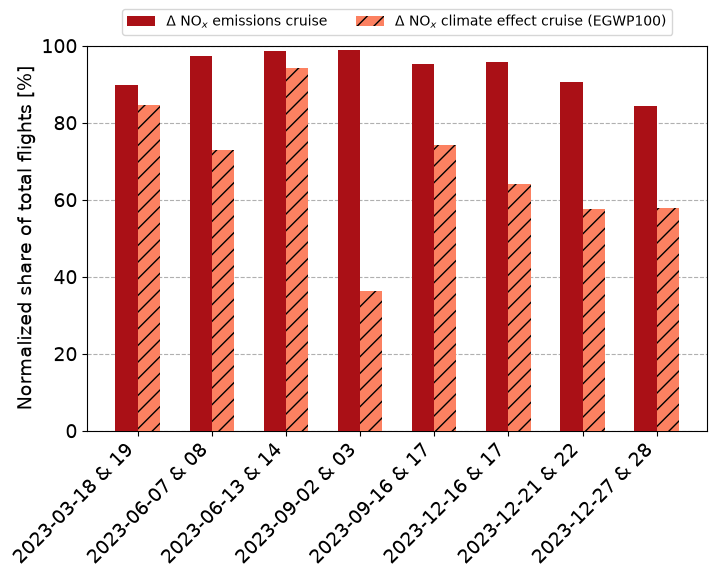

In [9]:
from cane.labels import friendly_days
from cane.colors import colormap_by_species

cols = ["nox_diff", "NOx_diff"]
friendly_cols = ["$\Delta \ $NO$_x$ emissions cruise", "$\Delta \ $NO$_x$ climate effect cruise (EGWP100)"]
x = np.arange(len(friendly_days))
width = 0.3

colors = [sns.color_palette("Reds")[5], sns.color_palette("Reds")[2]]
hatches = ["", "//"]

fig, ax = plt.subplots(figsize=(8, 5))

# Plot each column as a bar group
for i, col in enumerate(cols):
    ax.bar(
        x + (i - len(cols) / 2) * width + width / 2,  # center bars
        res_rel[col],
        width,
        label=friendly_cols[i],
        color=colors[i],
        hatch=hatches[i],
        zorder=10,
    )

ax.set_ylabel("Normalized share of total flights [%]", fontsize=14)
ax.set_ylim([0, 100])
ax.tick_params(axis='y', labelsize=14)

ax.set_xticks(x)
ax.set_xticklabels(friendly_days, fontsize=14, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--")
ax.grid(False, axis='x')

# plt.legend(facecolor='white', framealpha=1, loc='lower right')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=3)
# plt.savefig("../figures/fig04.png", dpi=300, bbox_inches='tight')

In [10]:
min_fl_diff_per_flight = dff.groupby("flight_id").agg({"fl_diff": "min", "day": "first"})
print(min_fl_diff_per_flight.fl_diff.median(), min_fl_diff_per_flight.fl_diff.mean())
min_fl_diff_per_flight.groupby("day").mean()

-44.0 -54.927772373540854


,fl_diff
day,
1,-58.769231
2,-51.383178
3,-42.875912
4,-31.352349
5,-50.598338
6,-58.779355
7,-58.271635
8,-68.304425


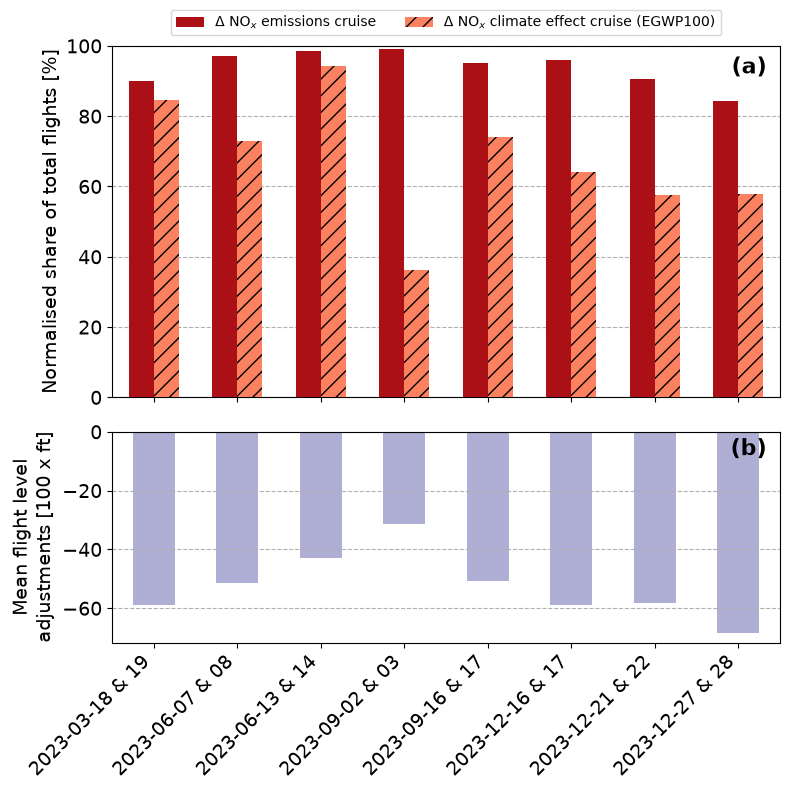

In [11]:
from cane.labels import friendly_days
from cane.colors import colormap_by_species

cols = ["nox_diff", "NOx_diff"]
friendly_cols = ["$\Delta \ $NO$_x$ emissions cruise", "$\Delta \ $NO$_x$ climate effect cruise (EGWP100)"]
x = np.arange(len(friendly_days))
width = 0.3

colors = [sns.color_palette("Reds")[5], sns.color_palette("Reds")[2]]
hatches = ["", "//"]

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True,
    gridspec_kw={'height_ratios': [1, 0.6]}
)

# --- Top ---
for i, col in enumerate(cols):
    ax.bar(
        x + (i - len(cols) / 2) * width + width / 2,  # center bars
        res_rel[col],
        width,
        label=friendly_cols[i],
        color=colors[i],
        hatch=hatches[i],
        zorder=10,
    )

ax.set_ylabel("Normalised share of total flights [%]", fontsize=14)
ax.set_ylim([0, 100])
ax.tick_params(axis='y', labelsize=14)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=3)
ax.grid(axis="y", linestyle="--")
ax.grid(False, axis='x')

# --- Bottom ---
min_fl_diff_per_flight.groupby("day").mean().plot.bar(ax=ax2, color=sns.color_palette("Purples")[2], width=0.5)

ax2.set_xlabel('', fontsize=14)
ax2.set_ylabel('Mean flight level\nadjustments [100 x ft]', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(friendly_days, fontsize=14, rotation=45, ha="right")
ax2.tick_params(axis='y', labelsize=14)
ax2.legend().set_visible(False)
ax2.grid(axis="y", linestyle="--")
ax2.grid(False, axis='x')

ax.text(
    0.98, 0.97, "(a)", zorder=100,
    transform=ax.transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="right"
)

ax2.text(
    0.98, 0.97, "(b)",
    transform=ax2.transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="right"
)

plt.tight_layout()
plt.savefig("../figures/fig04.png", dpi=300, bbox_inches='tight')